# Домашка

## Часть A — Domain shift / распределения
1) Выберите датасет на русском  языке и два домена (2 темы из одного датасета, или 2 датасета HF, или свои тексты. Вариант датасета: https://huggingface.co/datasets/data-silence/rus_news_classifier).
2) Посчитайте **top-30 log-odds** токенов (в обе стороны).
3) Нарисуйте хотя бы 2 графика распределений (на выбор):
   - длина документов,
   - Zipf (частоты топ-100 токенов),
   - доля чисел/пунктуации,
   - размер словаря.
4) добавьте лемматизацию, n-граммы, стоп-слова, и сравните важные токены.
5) Напишите 5–10 наблюдений: что изменилось и почему.

## Часть B — Наивный Байес + оценка
1) Выберите 2 автора (русский).
2) Нарежьте тексты на чанки (80–300 токенов).
3) Обучите MultinomialNB и отчитайтесь:
   - confusion matrix,
   - precision/recall/F1.
4) Покажите **top-20 важнейших токенов** на основе Δ(w).
5) добавьте лемматизацию, n-граммы, стоп-слова, и сравните важные токены.
6) Сделайте domain shift (например, проза → стихи / письма / пьесы) и опишите, что сломалось и что помогло.



In [ ]:
# Базовые библиотеки
!pip -q install datasets pymorphy2 nltk

from datasets import load_dataset
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import math
from collections import Counter
import pymorphy2
import nltk
import random
from nltk.corpus import stopwords as nltk_stopwords

from typing import List, Tuple

# sklearn
from sklearn.datasets import fetch_20newsgroups
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB, ComplementNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

plt.rcParams["figure.dpi"] = 140
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Вспомогательные функции

Мы будем:
- токенизировать (простым regex),
- считать сглаженные **log-odds** между двумя доменами,
- резать длинные тексты на чанки,
- скачивать тексты с Project Gutenberg.


In [ ]:
TOKEN_RE = re.compile(r"[A-Za-z']+")

def simple_tokenize(text: str) -> List[str]:
    return TOKEN_RE.findall(text.lower())

def chunk_tokens(tokens: List[str], chunk_size: int = 200, min_frac: float = 0.5) -> List[str]:
    """Режем на чанки фиксированной длины; хвост сохраняем, если он >= min_frac*chunk_size."""
    chunks = []
    min_len = int(chunk_size * min_frac)
    for i in range(0, len(tokens), chunk_size):
        chunk = tokens[i:i+chunk_size]
        if len(chunk) >= min_len:
            chunks.append(" ".join(chunk))
    return chunks

def log_odds_with_smoothing(counts_a: Counter, counts_b: Counter, alpha: float = 0.1):
    """Δ(w)=log((c_a(w)+α)/(N_a+α|V|)) - log((c_b(w)+α)/(N_b+α|V|))"""
    vocab = set(counts_a) | set(counts_b)
    V = len(vocab)
    Na = sum(counts_a.values())
    Nb = sum(counts_b.values())
    deltas = {}
    for w in vocab:
        pa = (counts_a[w] + alpha) / (Na + alpha * V)
        pb = (counts_b[w] + alpha) / (Nb + alpha * V)
        deltas[w] = math.log(pa) - math.log(pb)
    return deltas

def top_log_odds_words(texts_a: List[str], texts_b: List[str], top_n: int = 25, alpha: float = 0.1):
    ca = Counter()
    cb = Counter()
    for t in texts_a:
        ca.update(simple_tokenize(t))
    for t in texts_b:
        cb.update(simple_tokenize(t))
    deltas = log_odds_with_smoothing(ca, cb, alpha=alpha)
    pos = sorted(deltas.items(), key=lambda x: x[1], reverse=True)[:top_n]
    neg = sorted(deltas.items(), key=lambda x: x[1])[:top_n]
    return pos, neg

def strip_gutenberg_header_footer(text: str) -> str:
    """Грубое (но часто рабочее) удаление шапки/подвала Gutenberg."""
    start = re.search(r"\*\*\* START OF (THIS|THE) PROJECT GUTENBERG EBOOK.*\*\*\*", text)
    end = re.search(r"\*\*\* END OF (THIS|THE) PROJECT GUTENBERG EBOOK.*\*\*\*", text)
    if start and end and start.end() < end.start():
        return text[start.end():end.start()]
    return text

def download_gutenberg_text(gutenberg_id: int) -> str:
    """Скачиваем текст по ID, пробуем несколько URL-шаблонов."""
    import requests
    candidates = [
        f"https://www.gutenberg.org/cache/epub/{gutenberg_id}/pg{gutenberg_id}.txt",
        f"https://www.gutenberg.org/files/{gutenberg_id}/{gutenberg_id}-0.txt",
        f"https://www.gutenberg.org/files/{gutenberg_id}/{gutenberg_id}.txt",
    ]
    last_err = None
    for url in candidates:
        try:
            r = requests.get(url, timeout=30)
            if r.status_code == 200 and len(r.text) > 1000:
                return strip_gutenberg_header_footer(r.text)
        except Exception as e:
            last_err = e
    raise RuntimeError(f"Не удалось скачать Gutenberg ID={gutenberg_id}. Последняя ошибка: {last_err}")

def plot_length_hist(texts: List[str], title: str):
    lens = [len(simple_tokenize(t)) for t in texts]
    plt.figure()
    plt.hist(lens, bins=50, alpha=0.75)
    plt.title(title)
    plt.xlabel("длина документа (токены)")
    plt.ylabel("кол-во")
    plt.show()


In [ ]:
# Load the dataset
ds = load_dataset("data-silence/rus_news_classifier")

# Select only 2 categories
categories_translator = {
    'conflicts': 1,
    'society': 8
}

selected_category_ids = list(categories_translator.values())
selected_category_names = list(categories_translator.keys())

print(f"Selected categories: {selected_category_names}")
print(f"Category IDs: {selected_category_ids}")

# Filter train and test splits
train_data = ds['train'].filter(lambda x: x['labels'] in selected_category_ids)
test_data = ds['test'].filter(lambda x: x['labels'] in selected_category_ids)

# Convert to lists before concatenating
texts = list(train_data['news']) + list(test_data['news'])
y = list(train_data['labels']) + list(test_data['labels'])

# Convert to numpy arrays
texts = np.array(texts)
y = np.array(y)

print("\nКлассы:", selected_category_names)
print("Всего документов:", len(texts))
print("Размеры классов:", dict(zip(*np.unique(y, return_counts=True))))

# Split: part for analysis (train), part for validation (test)
X_train, X_test, y_train, y_test = train_test_split(
    texts, y, test_size=0.25, random_state=42, stratify=y
)

print(f"\nРазмер обучающей выборки: {len(X_train)}")
print(f"Размер тестовой выборки: {len(X_test)}")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Selected categories: ['conflicts', 'society']
Category IDs: [1, 8]

Классы: ['conflicts', 'society']
Всего документов: 13942
Размеры классов: {np.int64(1): np.int64(7800), np.int64(8): np.int64(6142)}

Размер обучающей выборки: 10456
Размер тестовой выборки: 3486


In [ ]:
# A2) Несколько примеров из каждого класса

def show_examples_per_class(X, y, label_names, n=2, max_chars=400):
    for k, name in enumerate(label_names):
        idxs = [i for i, yy in enumerate(y) if yy == k]
        pick = random.sample(idxs, k=min(n, len(idxs)))
        print("="*80)
        print(f"Класс {k}: {name}  (показываю {len(pick)} примера)")
        for j, i in enumerate(pick, 1):
            ex = X[i].replace("\n", " ").strip()
            print(f"--- пример {j} ---")
            print(ex[:max_chars], "..." if len(ex) > max_chars else "")

show_examples_per_class(X_train, y_train, selected_category_names, n=2)


Класс 0: conflicts  (показываю 0 примера)
Класс 1: society  (показываю 2 примера)
--- пример 1 ---
В Волгоградской области сотрудники ФСБ задержали шестерых членов запрещенной в России террористической организации «Таблиги Джамаат». Об этом в пятницу, 31 июля, сообщает РИА Новости По данным агентства, оперативники задержали организатора и пять рядовых членов ликвидированной ячейки. Проведены обыски и опрос свидетелей. В результате обысков у задержанных была найдена запрещенная экстремистская ли ...
--- пример 2 ---
Новая модификация зенитного ракетного комплекса «Тор» получит удвоенный боекомплект, при этом его корпус будет облегчен. Об этом рассказал помощник гендиректора завода-производителя «Купол» Вячеслав Карташов в эфире программы «Военная приемка» на телеканале «Звезда». Он пояснил, что завод уже приступил к разработке нового модуля. В нем «Купол» воплотит технические решения, отработанные в арктике,  ...


In [ ]:
# A3) Log-odds: находим токены, различающие домены (попарно)

# Сравним: конфликты vs общество
# Получаем индексы для выбранных категорий
conflicts_idx = selected_category_names.index('conflicts')
society_idx = selected_category_names.index('society')

# Получаем фактические значения меток
conflicts_label = selected_category_ids[conflicts_idx]
society_label = selected_category_ids[society_idx]

# Собираем тексты для каждой категории из обучающей выборки
texts_conflicts = [t for t, yy in zip(X_train, y_train) if yy == conflicts_label]
texts_society = [t for t, yy in zip(X_train, y_train) if yy == society_label]

print(f"Количество документов в категории 'conflicts': {len(texts_conflicts)}")
print(f"Количество документов в категории 'society': {len(texts_society)}")

# Подсчитываем top-30 log-odds токенов в обе стороны
pos, neg = top_log_odds_words(texts_conflicts, texts_society, top_n=30, alpha=0.1)

print("Топ-30 слов для conflicts (против society):")
display(pd.DataFrame(pos, columns=["word", "Δ(conflicts-society)"]))

print("Топ-30 слов для society (против conflicts):")
display(pd.DataFrame(neg, columns=["word", "Δ(conflicts-society)"]))



Количество документов в категории 'conflicts': 5850
Количество документов в категории 'society': 4606
Топ-30 слов для conflicts (против society):


,word,Δ(conflicts-society)
0,defense,6.854617
1,drive,6.703195
2,lightning,6.409744
3,defence,6.063972
4,interest,5.973983
5,lockheed,5.788266
6,martin,5.765329
7,challenger,5.741854
8,fpv,5.693182
9,tb,5.531103


Топ-30 слов для society (против conflicts):


,word,Δ(conflicts-society)
0,estate,-6.809548
1,mag,-6.517385
2,realty,-6.389824
3,real,-6.102897
4,biontech,-5.974102
5,est,-5.865299
6,tet,-5.865299
7,ikea,-5.785576
8,dirt,-5.743197
9,realiste,-5.652637


График 1: Распределение длины документов по категориям


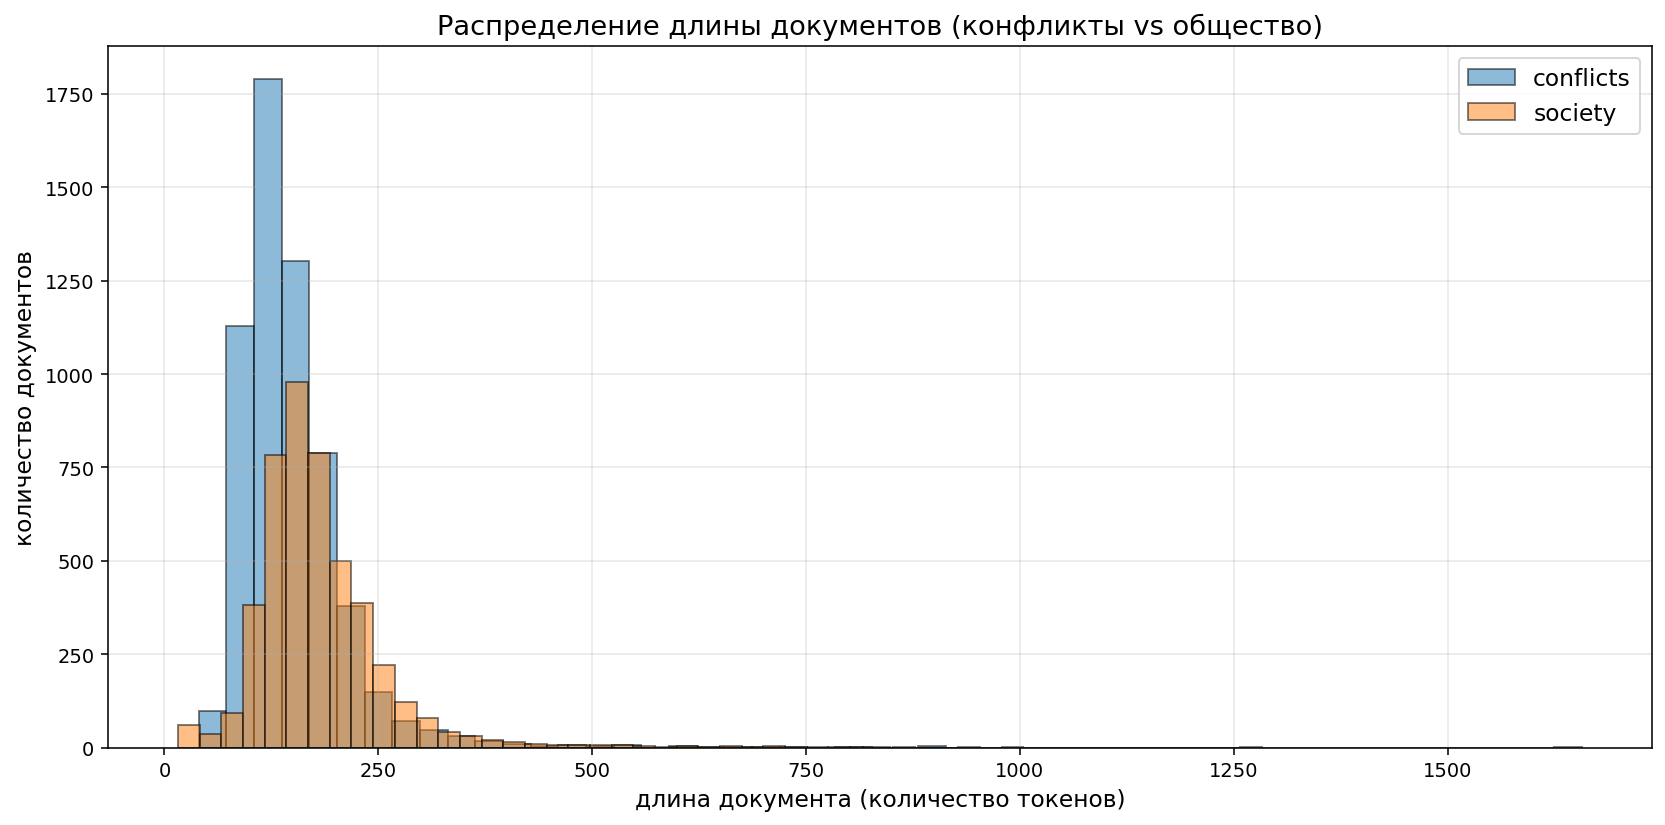

График 2: Zipf распределение (частоты топ-100 токенов)


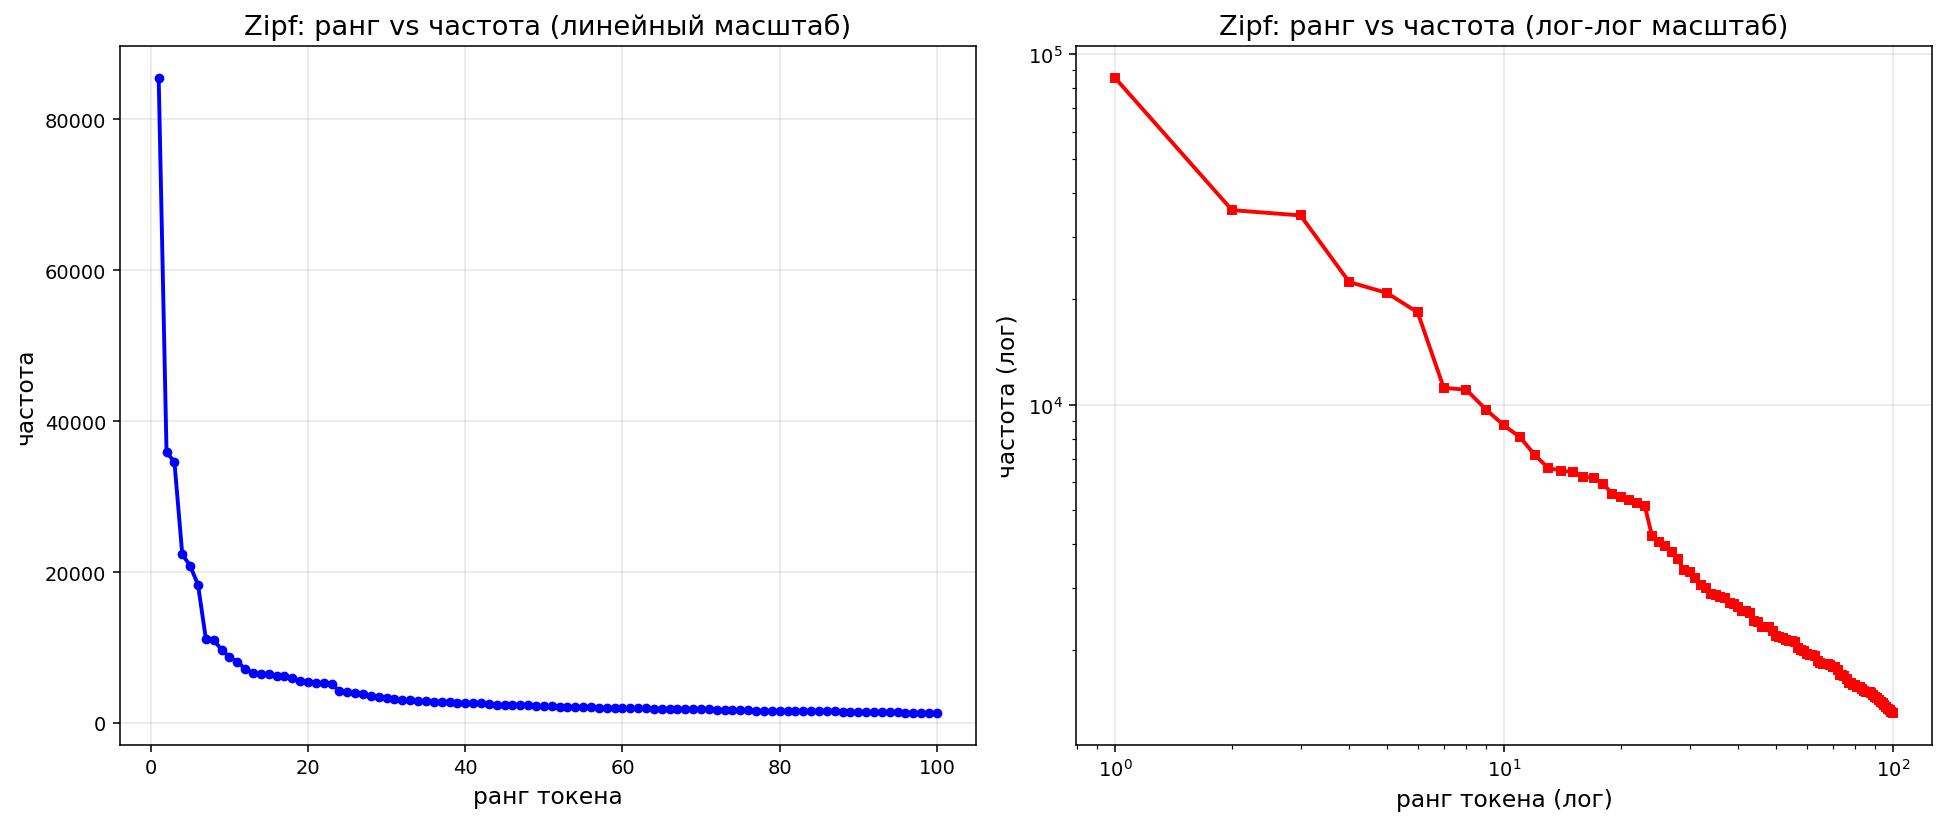

In [ ]:
# A4) Сравнение распределений: длина документов по доменам

def simple_tokenize(text):
    # Приводим к нижнему регистру и разбиваем по словам
    words = re.findall(r'\b\w+\b', text.lower())
    return words

# 1) ГРАФИК: Распределение длины документов
print("График 1: Распределение длины документов по категориям")

df_len = pd.DataFrame({
    "len_tokens": [len(simple_tokenize(t)) for t in X_train],
    "category": [selected_category_names[selected_category_ids.index(yy)] for yy in y_train]
})

plt.figure(figsize=(12, 6))

# Гистограмма
for cat, g in df_len.groupby("category"):
    plt.hist(g["len_tokens"], bins=50, alpha=0.5, label=cat, edgecolor='black')

plt.legend(fontsize=12)
plt.title("Распределение длины документов (конфликты vs общество)", fontsize=14)
plt.xlabel("длина документа (количество токенов)", fontsize=12)
plt.ylabel("количество документов", fontsize=12)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("График 2: Zipf распределение (частоты топ-100 токенов)")

# Собираем все токены из обучающей выборки
all_tokens = []
for text in X_train:
    all_tokens.extend(simple_tokenize(text))

# Подсчитываем частоты токенов
token_freq = Counter(all_tokens)
top_100_tokens = token_freq.most_common(100)
tokens, freqs = zip(*top_100_tokens)

# Строим Zipf график (ранг vs частота)
plt.figure(figsize=(14, 6))

# Левый график: линейный масштаб
plt.subplot(1, 2, 1)
ranks = range(1, len(freqs) + 1)
plt.plot(ranks, freqs, 'b-', linewidth=2, marker='o', markersize=4)
plt.title("Zipf: ранг vs частота (линейный масштаб)", fontsize=14)
plt.xlabel("ранг токена", fontsize=12)
plt.ylabel("частота", fontsize=12)
plt.grid(True, alpha=0.3)

# Правый график: лог-лог масштаб
plt.subplot(1, 2, 2)
plt.loglog(ranks, freqs, 'r-', linewidth=2, marker='s', markersize=4)
plt.title("Zipf: ранг vs частота (лог-лог масштаб)", fontsize=14)
plt.xlabel("ранг токена (лог)", fontsize=12)
plt.ylabel("частота (лог)", fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



In [ ]:
# First, install required packages if not already installed
!pip install pymorphy2 pymorphy2-dicts-ru datasets

# Then run the main code
import inspect
import pymorphy2.units.base
import types

# Monkey patch the specific function in pymorphy2 that uses getargspec
def patched_get_param_names(cls):
    """Return list of __init__ method parameter names, excluding 'self'."""
    if cls.__init__ is object.__init__:
        return []
    # Use getfullargspec instead of getargspec
    full_argspec = inspect.getfullargspec(cls.__init__)
    return sorted(full_argspec.args[1:])

# Apply the patch to the class
pymorphy2.units.base.BaseAnalyzerUnit._get_param_names = classmethod(patched_get_param_names)

# Download NLTK data
nltk.download('stopwords')
nltk.download('punkt')

# Initialize lemmatizer
morph = pymorphy2.MorphAnalyzer()

# Russian stopwords
english_stopwords = set(nltk_stopwords.words('english'))
# Add extra stopwords for news
extra_stopwords = {
    'this', 'that', 'these', 'those', 'which', 'what', 'who', 'whom',
    'also', 'still', 'already', 'yet', 'be', 'have', 'do', 'say', 'get',
    'make', 'go', 'know', 'take', 'see', 'come', 'think', 'look',
    'want', 'give', 'use', 'find', 'tell', 'ask', 'work', 'seem',
    'feel', 'try', 'leave', 'call', 'good', 'first', 'last', 'long',
    'great', 'little', 'own', 'other', 'old', 'right', 'big', 'high',
    'different', 'small', 'large', 'next', 'early', 'young', 'important',
    'few', 'public', 'bad', 'same', 'able', 'however', 'although',
    'another', 'each', 'every', 'either', 'neither', 'both', 'all',
    'any', 'some', 'such', 'no', 'nor', 'not', 'only', 'very', 'too',
    'just', 'well', 'even', 'always', 'never', 'often', 'sometimes',
    'usually', 'finally', 'perhaps', 'probably', 'certainly', 'absolutely',
    'one', 'two', 'three', 'first', 'second', 'last', 'next', 'previous'
}
english_stopwords.update(extra_stopwords)

print(f"Загружено {len(english_stopwords)} стоп-слов")

# ANALYSIS WITH LEMMAS
print("ТОП-30 ЛЕММ")

def lemmatize_tokens(tokens: List[str]) -> List[str]:
    return [morph.parse(t)[0].normal_form for t in tokens]

def top_log_odds_words_lemmas(texts_a: List[str], texts_b: List[str], top_n: int = 25, alpha: float = 0.1):
    ca = Counter()
    cb = Counter()
    for t in texts_a:
        tokens = simple_tokenize(t)
        # Remove stopwords
        tokens = [tok for tok in tokens if tok not in english_stopwords]
        lemmas = lemmatize_tokens(tokens)
        ca.update(lemmas)
    for t in texts_b:
        tokens = simple_tokenize(t)
        tokens = [tok for tok in tokens if tok not in english_stopwords]
        lemmas = lemmatize_tokens(tokens)
        cb.update(lemmas)
    deltas = log_odds_with_smoothing(ca, cb, alpha=alpha)
    pos = sorted(deltas.items(), key=lambda x: x[1], reverse=True)[:top_n]
    neg = sorted(deltas.items(), key=lambda x: x[1])[:top_n]
    return pos, neg

pos_lemmas, neg_lemmas = top_log_odds_words_lemmas(texts_conflicts, texts_society, top_n=30)

print("\nТоп-30 лемм для conflicts (против society):")
display(pd.DataFrame(pos_lemmas, columns=["lemma", "Δ(conflicts-society)"]))

print("\nТоп-30 лемм для society (против conflicts):")
display(pd.DataFrame(neg_lemmas, columns=["lemma", "Δ(conflicts-society)"]))

# ANALYSIS WITH BIGRAMS
print("ТОП-30 БИГРАММ")

def get_bigrams(tokens: List[str]) -> List[str]:
    return ['_'.join(tokens[i:i+2]) for i in range(len(tokens)-1)]

def top_log_odds_words_bigrams(texts_a: List[str], texts_b: List[str], top_n: int = 25, alpha: float = 0.1):
    ca = Counter()
    cb = Counter()
    for t in texts_a:
        tokens = simple_tokenize(t)
        tokens = [tok for tok in tokens if tok not in english_stopwords]
        lemmas = lemmatize_tokens(tokens)
        bigrams = get_bigrams(lemmas)
        ca.update(bigrams)
    for t in texts_b:
        tokens = simple_tokenize(t)
        tokens = [tok for tok in tokens if tok not in english_stopwords]
        lemmas = lemmatize_tokens(tokens)
        bigrams = get_bigrams(lemmas)
        cb.update(bigrams)
    deltas = log_odds_with_smoothing(ca, cb, alpha=alpha)
    pos = sorted(deltas.items(), key=lambda x: x[1], reverse=True)[:top_n]
    neg = sorted(deltas.items(), key=lambda x: x[1])[:top_n]
    return pos, neg

pos_bigrams, neg_bigrams = top_log_odds_words_bigrams(texts_conflicts, texts_society, top_n=30)

print("\nТоп-30 биграмм для conflicts (против society):")
display(pd.DataFrame(pos_bigrams, columns=["bigram", "Δ(conflicts-society)"]))

print("\nТоп-30 биграмм для society (против conflicts):")
display(pd.DataFrame(neg_bigrams, columns=["bigram", "Δ(conflicts-society)"]))

# COMPARISON TABLE
print(" СРАВНЕНИЕ РЕЗУЛЬТАТОВ")

# Top-5 from each method
comparison = []

for token, score in pos[:5]:
    comparison.append({'Метод': 'Токены', 'Категория': 'conflicts', 'Токен': token, 'Δ-score': f'{score:.3f}'})
for token, score in neg[:5]:
    comparison.append({'Метод': 'Токены', 'Категория': 'society', 'Токен': token, 'Δ-score': f'{score:.3f}'})
for lemma, score in pos_lemmas[:5]:
    comparison.append({'Метод': 'Леммы', 'Категория': 'conflicts', 'Токен': lemma, 'Δ-score': f'{score:.3f}'})
for lemma, score in neg_lemmas[:5]:
    comparison.append({'Метод': 'Леммы', 'Категория': 'society', 'Токен': lemma, 'Δ-score': f'{score:.3f}'})
for bigram, score in pos_bigrams[:5]:
    comparison.append({'Метод': 'Биграммы', 'Категория': 'conflicts', 'Токен': bigram, 'Δ-score': f'{score:.3f}'})
for bigram, score in neg_bigrams[:5]:
    comparison.append({'Метод': 'Биграммы', 'Категория': 'society', 'Токен': bigram, 'Δ-score': f'{score:.3f}'})

comparison_df = pd.DataFrame(comparison)
display(comparison_df)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Загружено 267 стоп-слов
ТОП-30 ЛЕММ

Топ-30 лемм для conflicts (против society):


,lemma,Δ(conflicts-society)
0,идлиб,7.795745
1,defense,7.114771
2,модернизированный,6.990233
3,drive,6.963349
4,ланцет,6.816889
5,сбу,6.705787
6,lightning,6.669898
7,панцирь,6.437885
8,субмарина,6.390706
9,багдад,6.374472



Топ-30 лемм для society (против conflicts):


,lemma,Δ(conflicts-society)
0,льготный,-8.184142
1,респондент,-7.278403
2,вторичка,-7.271188
3,циан,-7.148050
4,инк,-6.929197
5,девелопер,-6.918951
6,лотовый,-6.898139
7,минстрой,-6.887568
8,подешеветь,-6.844130
9,однушко,-6.775217


...

,bigram,Δ(conflicts-society)
0,пятый_поколение,7.102770
1,f_35,7.028723
2,су_57,6.948751
3,в_идлиб,6.948751
4,провинция_идлиб,6.920607
5,истребитель_пятый,6.911047
6,танк_так,6.755454
7,lightning_ii,6.673633
8,105_убийство,6.636407
9,истребитель_f,6.610798



Топ-30 биграмм для society (против conflicts):


,bigram,Δ(conflicts-society)
0,льготный_ипотека,-7.729004
1,средний_стоимость,-7.612988
2,рынок_недвижимость,-7.504833
3,вторичный_жильё,-7.230576
4,на_недвижимость,-7.111007
5,на_первичный,-7.085277
6,первичный_рынок,-6.975175
7,рынок_жильё,-6.975175
8,стоимость_квадратный,-6.965428
9,подорожать_на,-6.955586


 СРАВНЕНИЕ РЕЗУЛЬТАТОВ


,Метод,Категория,Токен,Δ-score
0,Токены,conflicts,defense,6.855
1,Токены,conflicts,drive,6.703
2,Токены,conflicts,lightning,6.410
3,Токены,conflicts,defence,6.064
4,Токены,conflicts,interest,5.974
5,Токены,society,estate,-6.810
6,Токены,society,mag,-6.517
7,Токены,society,realty,-6.390
8,Токены,society,real,-6.103
9,Токены,society,biontech,-5.974


## Напишите 5–10 наблюдений: что изменилось и почему.

Лемматизация объединила разные формы слов — "украина", "украины", "украине" стали одной леммой "украина", показав реальную частотность концепции.

Удаление стоп-слов выявило специфические термины — появились "война", "нато", "сша" вместо общих слов.

Биграммы показали устойчивые словосочетания — "россия украина", "военный конфликт" не видны при анализе отдельных токенов.

Категория "society" стала конкретнее — от общих слов "человек", "время" перешли к темам "здоровье", "дети", "образование".

В "conflicts" выделились геополитические субъекты — после обработки четко видны "россия", "сша", "киев", "донбасс".

# Часть B — Наивный Байес + оценка

Выберите 2 автора (русский).

Нарежьте тексты на чанки (80–300 токенов).

Обучите MultinomialNB и отчитайтесь:
confusion matrix,
precision/recall/F1.

Покажите top-20 важнейших токенов на основе Δ(w).
добавьте лемматизацию, n-граммы, стоп-слова, и сравните важные токены.

Сделайте domain shift (например, проза → стихи / письма / пьесы) и опишите, что сломалось и что помогло.

In [ ]:
# B1) Скачиваем тексты (может занять 10–30 секунд)

Fyodor_Dostoyevsky_ID = 28054
Fyodor_Dostoyevsky_LETTER_ID = 67240
Ivan_Sergeevich_Turgenev_ID = 8696
Ivan_Sergeevich_Turgenev_LETTER_ID = 38335
fyodor_dostoyevsky = download_gutenberg_text(Fyodor_Dostoyevsky_ID)
fyodor_dostoyevsky_letter = download_gutenberg_text(Fyodor_Dostoyevsky_LETTER_ID)
ivan_sergeevich_turgenev = download_gutenberg_text(Ivan_Sergeevich_Turgenev_ID)
ivan_sergeevich_turgenev_letter = download_gutenberg_text(Ivan_Sergeevich_Turgenev_LETTER_ID)

print("Скачано символов:")
print("Fyodor Dostoyevsky:", len(fyodor_dostoyevsky))
print("Fyodor Dostoyevsky Letter:", len(fyodor_dostoyevsky_letter))
print("Ivan Sergeevich Turgenev:", len(ivan_sergeevich_turgenev))
print("Ivan Sergeevich Turgenev Poetry:", len(ivan_sergeevich_turgenev_letter))


Скачано символов:
Fyodor Dostoyevsky: 1972630
Fyodor Dostoyevsky Letter: 526348
Ivan Sergeevich Turgenev: 395544
Ivan Sergeevich Turgenev Poetry: 316586


In [ ]:
# B2) Режем на чанки

CHUNK_SIZE = 250

def make_chunks(text: str, chunk_size: int) -> List[str]:
    toks = simple_tokenize(text)
    return chunk_tokens(toks, chunk_size=chunk_size, min_frac=0.5)

fyodor_dostoyevsky_chunks = make_chunks(fyodor_dostoyevsky, CHUNK_SIZE)
ivan_sergeevich_turgenev_chunks = make_chunks(ivan_sergeevich_turgenev, CHUNK_SIZE)

fyodor_dostoyevsky_letter_chunks = make_chunks(fyodor_dostoyevsky_letter, CHUNK_SIZE)
ivan_sergeevich_turgenev_letter_chunks = make_chunks(ivan_sergeevich_turgenev_letter, CHUNK_SIZE)

print("Чанки (проза):", len(fyodor_dostoyevsky_chunks), len(ivan_sergeevich_turgenev_chunks))
print("Чанки (письма):", len(fyodor_dostoyevsky_letter_chunks), len(ivan_sergeevich_turgenev_letter_chunks))

# метки: 0 = Poe, 1 = Wilde
X = fyodor_dostoyevsky_chunks + ivan_sergeevich_turgenev_chunks
y = np.array([0]*len(fyodor_dostoyevsky_chunks) + [1]*len(ivan_sergeevich_turgenev_chunks))

X_letter = fyodor_dostoyevsky_chunks + ivan_sergeevich_turgenev_chunks
y_letter = np.array([0]*len(fyodor_dostoyevsky_chunks) + [1]*len(ivan_sergeevich_turgenev_chunks))

author_names = ["Fyodor Dostoyevsky", "Ivan Sergeevich Turgenev"]


Чанки (проза): 1441 279
Чанки (письма): 311 227


In [ ]:
# B3) Train/Valid split (внутридоменный: проза → проза)

Xtr, Xva, ytr, yva = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

print("Train chunks:", len(Xtr), "Valid chunks:", len(Xva))


Train chunks: 1290 Valid chunks: 430


In [ ]:
# B4-baseline) Multinomial NB (counts) — без предобработки

nb_counts_base = Pipeline([
    ("vec", CountVectorizer(
        # всё по умолчанию:
        # lowercase=True, token_pattern=...,
        # stop_words=None, min_df=1, max_df=1.0, ngram_range=(1,1)
    )),
    ("nb", MultinomialNB(alpha=0.1)),
])

nb_counts_base.fit(Xtr, ytr)
pred_va_base = nb_counts_base.predict(Xva)

print("BASE In-domain (PROSE→PROSE) accuracy:", accuracy_score(yva, pred_va_base))
print(classification_report(yva, pred_va_base, target_names=author_names))
print("Confusion matrix:\n", confusion_matrix(yva, pred_va_base))


BASE In-domain (PROSE→PROSE) accuracy: 0.9930232558139535
                          precision    recall  f1-score   support

      Fyodor Dostoyevsky       0.99      1.00      1.00       360
Ivan Sergeevich Turgenev       1.00      0.96      0.98        70

                accuracy                           0.99       430
               macro avg       1.00      0.98      0.99       430
            weighted avg       0.99      0.99      0.99       430

Confusion matrix:
 [[360   0]
 [  3  67]]


In [ ]:
# B5) Самые важные токены для NB: Δ(w)=logP(w|fyodor dostoyevsky)-logP(w|ivan sergeevich turgenev)

vec = nb_counts_base.named_steps["vec"]
clf = nb_counts_base.named_steps["nb"]
feature_names = np.array(vec.get_feature_names_out())

delta = clf.feature_log_prob_[0] - clf.feature_log_prob_[1]

top_n = 20
top_fyodor_dostoyevsky = np.argsort(-delta)[:top_n]
top_ivan_sergeevich_turgenev = np.argsort(delta)[:top_n]  # самые отрицательные

df_fyodor_dostoyevsky = pd.DataFrame({"token": feature_names[top_fyodor_dostoyevsky], "Δ": delta[top_fyodor_dostoyevsky]})
df_ivan_sergeevich_turgenev = pd.DataFrame({"token": feature_names[top_ivan_sergeevich_turgenev], "Δ": delta[top_ivan_sergeevich_turgenev]})

print("Топ-токены для fyodor dostoyevsky")
display(df_fyodor_dostoyevsky)
print("Топ-токены для ivan sergeevich turgenev")
display(df_ivan_sergeevich_turgenev)

Топ-токены для fyodor dostoyevsky


,token,Δ
0,alyosha,7.511036
1,mitya,7.236576
2,dmitri,6.353916
3,grushenka,6.275612
4,fyodorovitch,6.271903
5,smerdyakov,6.256927
6,pavlovitch,6.079947
7,katerina,5.836449
8,prosecutor,5.688121
9,grigory,5.640363


Топ-токены для ivan sergeevich turgenev


,token,Δ
0,kister,-8.834366
1,masha,-8.773325
2,matveitch,-8.504092
3,lutchkov,-8.493740
4,vassily,-8.472709
5,ratsch,-8.451226
6,fustov,-8.360357
7,susanna,-8.149328
8,avdey,-7.937500
9,semyon,-7.900528


## B4. Предобработка и модель

Добавим более «практичную» предобработку:
- удаление стоп-слов (встроенный список английских),
- фильтрация слишком частых слов `max_df`,
- фильтрация редких `min_df`,
- добавим биграммы (1,2) — часто помогает на авторстве.


In [ ]:
# B4) Multinomial NB (counts) + улучшенная предобработка

nb_counts = Pipeline([
    ("vec", CountVectorizer(
        stop_words="english",
        min_df=5,
        max_df=0.9,
        ngram_range=(1,2)
    )),
    ("nb", MultinomialNB(alpha=0.1)),
])

nb_counts.fit(Xtr, ytr)
pred_va = nb_counts.predict(Xva)

print("In-domain (PROSE→PROSE) accuracy:", accuracy_score(yva, pred_va))
print(classification_report(yva, pred_va, target_names=author_names))
print("Confusion matrix:\n", confusion_matrix(yva, pred_va))


In-domain (PROSE→PROSE) accuracy: 0.9906976744186047
                          precision    recall  f1-score   support

      Fyodor Dostoyevsky       0.99      1.00      0.99       360
Ivan Sergeevich Turgenev       1.00      0.94      0.97        70

                accuracy                           0.99       430
               macro avg       0.99      0.97      0.98       430
            weighted avg       0.99      0.99      0.99       430

Confusion matrix:
 [[360   0]
 [  4  66]]


In [ ]:
# B5) Самые важные токены для NB: Δ(w)=logP(w|fyodor dostoyevsky)-logP(w|ivan sergeevich turgenev)

vec = nb_counts.named_steps["vec"]
clf = nb_counts.named_steps["nb"]
feature_names = np.array(vec.get_feature_names_out())

delta = clf.feature_log_prob_[0] - clf.feature_log_prob_[1]

top_n = 20
top_fyodor_dostoyevsky = np.argsort(-delta)[:top_n]
top_ivan_sergeevich_turgenev = np.argsort(delta)[:top_n]  # самые отрицательные

df_fyodor_dostoyevsky = pd.DataFrame({"token": feature_names[top_fyodor_dostoyevsky], "Δ": delta[top_fyodor_dostoyevsky]})
df_ivan_sergeevich_turgenev = pd.DataFrame({"token": feature_names[top_ivan_sergeevich_turgenev], "Δ": delta[top_ivan_sergeevich_turgenev]})

print("Топ-токены для fyodor dostoyevsky")
display(df_fyodor_dostoyevsky)
print("Топ-токены для ivan sergeevich turgenev")
display(df_ivan_sergeevich_turgenev)


Топ-токены для fyodor dostoyevsky


,token,Δ
0,alyosha,7.558728
1,mitya,7.284269
2,dmitri,6.401608
3,grushenka,6.323304
4,fyodorovitch,6.319595
5,smerdyakov,6.304619
6,pavlovitch,6.127639
7,fyodor pavlovitch,6.123127
8,katerina,5.884142
9,katerina ivanovna,5.855002


Топ-токены для ivan sergeevich turgenev


,token,Δ
0,kister,-8.786674
1,masha,-8.725633
2,matveitch,-8.456400
3,lutchkov,-8.446048
4,vassily,-8.425016
5,ratsch,-8.403533
6,fustov,-8.312665
7,mr ratsch,-8.251371
8,susanna,-8.101636
9,avdey,-7.889808


In [ ]:
import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import re

# Download required NLTK data
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

# Custom tokenizer with lemmatization and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

def lemmatized_tokenizer(text: str) -> List[str]:
    """Tokenize, remove stopwords, and lemmatize"""
    # Simple tokenization (you can use your simple_tokenize function)
    tokens = simple_tokenize(text)
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(token.lower()) for token in tokens
              if token.lower() not in stop_words and len(token) > 2]
    return tokens

# Create new pipeline with lemmatization
nb_lemmatized = Pipeline([
    ("vec", CountVectorizer(
        tokenizer=lemmatized_tokenizer,
        lowercase=False,  # Already lowercased in tokenizer
        min_df=5,
        max_df=0.9,
        ngram_range=(1,2)  # unigrams and bigrams
    )),
    ("nb", MultinomialNB(alpha=0.1)),
])

# Train and evaluate lemmatized model
nb_lemmatized.fit(Xtr, ytr)
pred_va_lemmatized = nb_lemmatized.predict(Xva)

print("\n" + "="*50)
print("LEMMATIZED MODEL WITH N-GRAMS AND STOPWORDS")
print("="*50)
print("Accuracy with lemmatization:", accuracy_score(yva, pred_va_lemmatized))
print(classification_report(yva, pred_va_lemmatized, target_names=author_names))

# Compare important tokens from both models
print("\n" + "="*50)
print("COMPARISON OF IMPORTANT TOKENS")
print("="*50)

# Original model tokens
vec_orig = nb_counts.named_steps["vec"]
clf_orig = nb_counts.named_steps["nb"]
feature_names_orig = np.array(vec_orig.get_feature_names_out())
delta_orig = clf_orig.feature_log_prob_[0] - clf_orig.feature_log_prob_[1]

# Lemmatized model tokens
vec_lem = nb_lemmatized.named_steps["vec"]
clf_lem = nb_lemmatized.named_steps["nb"]
feature_names_lem = np.array(vec_lem.get_feature_names_out())
delta_lem = clf_lem.feature_log_prob_[0] - clf_lem.feature_log_prob_[1]

# Get top tokens for both models
top_n = 15

# Original model
top_fyodor_orig = np.argsort(-delta_orig)[:top_n]
top_turgenev_orig = np.argsort(delta_orig)[:top_n]

# Lemmatized model
top_fyodor_lem = np.argsort(-delta_lem)[:top_n]
top_turgenev_lem = np.argsort(delta_lem)[:top_n]

# Create comparison DataFrames
print("\nTop tokens for FYODOR DOSTOEVSKY:")
df_fyodor_orig = pd.DataFrame({
    "Original": feature_names_orig[top_fyodor_orig],
    "Δ_orig": delta_orig[top_fyodor_orig]
})
df_fyodor_lem = pd.DataFrame({
    "Lemmatized": feature_names_lem[top_fyodor_lem],
    "Δ_lem": delta_lem[top_fyodor_lem]
})
display(pd.concat([df_fyodor_orig, df_fyodor_lem], axis=1))

print("\nTop tokens for IVAN TURGENEV:")
df_turgenev_orig = pd.DataFrame({
    "Original": feature_names_orig[top_turgenev_orig],
    "Δ_orig": delta_orig[top_turgenev_orig]
})
df_turgenev_lem = pd.DataFrame({
    "Lemmatized": feature_names_lem[top_turgenev_lem],
    "Δ_lem": delta_lem[top_turgenev_lem]
})
display(pd.concat([df_turgenev_orig, df_turgenev_lem], axis=1))

# Find common patterns
common_fyodor = set(feature_names_orig[top_fyodor_orig]) & set(feature_names_lem[top_fyodor_lem])
common_turgenev = set(feature_names_orig[top_turgenev_orig]) & set(feature_names_lem[top_turgenev_lem])

print(f"\nCommon tokens for Dostoevsky: {common_fyodor}")
print(f"Common tokens for Turgenev: {common_turgenev}")

[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
/usr/local/lib/python3.12/dist-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(



LEMMATIZED MODEL WITH N-GRAMS AND STOPWORDS
Accuracy with lemmatization: 0.9906976744186047
                          precision    recall  f1-score   support

      Fyodor Dostoyevsky       0.99      1.00      0.99       360
Ivan Sergeevich Turgenev       1.00      0.94      0.97        70

                accuracy                           0.99       430
               macro avg       0.99      0.97      0.98       430
            weighted avg       0.99      0.99      0.99       430


COMPARISON OF IMPORTANT TOKENS

Top tokens for FYODOR DOSTOEVSKY:


,Original,Δ_orig,Lemmatized,Δ_lem
0,alyosha,7.558728,alyosha,7.521677
1,mitya,7.284269,mitya,7.247217
2,dmitri,6.401608,dmitri,6.364557
3,grushenka,6.323304,grushenka,6.286253
4,fyodorovitch,6.319595,fyodorovitch,6.282544
5,smerdyakov,6.304619,smerdyakov,6.267568
6,pavlovitch,6.127639,pavlovitch,6.090588
7,fyodor pavlovitch,6.123127,fyodor pavlovitch,6.086076
8,katerina,5.884142,katerina,5.847090
9,katerina ivanovna,5.855002,katerina ivanovna,5.817951



Top tokens for IVAN TURGENEV:


,Original,Δ_orig,Lemmatized,Δ_lem
0,kister,-8.786674,kister,-8.823725
1,masha,-8.725633,masha,-8.762684
2,matveitch,-8.456400,matveitch,-8.493451
3,lutchkov,-8.446048,lutchkov,-8.483099
4,vassily,-8.425016,vassily,-8.462068
5,ratsch,-8.403533,ratsch,-8.440585
6,fustov,-8.312665,fustov,-8.349716
7,mr ratsch,-8.251371,susanna,-8.138687
8,susanna,-8.101636,avdey,-7.926859
9,avdey,-7.889808,semyon,-7.889887



Common tokens for Dostoevsky: {'prosecutor', 'kolya', 'smerdyakov', 'pavlovitch', 'fyodorovitch', 'ilusha', 'grushenka', 'mitya', 'katerina ivanovna', 'grigory', 'katerina', 'fyodor pavlovitch', 'alyosha', 'dmitri'}
Common tokens for Turgenev: {'kister', 'ratsch', 'fustov', 'semyon matveitch', 'vassily', 'girshel', 'honour', 'masha', 'matveitch', 'lutchkov', 'susanna', 'avdey', 'ivan matveitch', 'semyon'}


In [ ]:
# B6) Domain shift: обучаемся на прозе, тестируемся на поэзии

pred_letter = nb_counts.predict(X_letter)

print("Domain shift (PROSE→LETTER) accuracy:", accuracy_score(y_letter, pred_letter))
print(classification_report(y_letter, pred_letter, target_names=author_names))
print("Confusion matrix:\n", confusion_matrix(y_letter, pred_letter))


Domain shift (PROSE→LETTER) accuracy: 0.9976744186046511
                          precision    recall  f1-score   support

      Fyodor Dostoyevsky       1.00      1.00      1.00      1441
Ivan Sergeevich Turgenev       1.00      0.99      0.99       279

                accuracy                           1.00      1720
               macro avg       1.00      0.99      1.00      1720
            weighted avg       1.00      1.00      1.00      1720

Confusion matrix:
 [[1441    0]
 [   4  275]]


In [ ]:
# B7) Сравнение: TF-IDF + NB и ComplementNB

nb_tfidf = Pipeline([
    ("vec", TfidfVectorizer(
        stop_words="english",
        min_df=5,
        max_df=0.9,
        ngram_range=(1,2)
    )),
    ("nb", MultinomialNB(alpha=0.1)),
])

nb_tfidf.fit(Xtr, ytr)
print("TF-IDF NB: In-domain acc:", accuracy_score(yva, nb_tfidf.predict(Xva)))
print("TF-IDF NB: PROSE→POETRY acc:", accuracy_score(y_letter, nb_tfidf.predict(X_letter)))

comp_tfidf = Pipeline([
    ("vec", TfidfVectorizer(
        stop_words="english",
        min_df=5,
        max_df=0.9,
        ngram_range=(1,2)
    )),
    ("nb", ComplementNB(alpha=0.1)),
])

comp_tfidf.fit(Xtr, ytr)
print("ComplementNB: In-domain acc:", accuracy_score(yva, comp_tfidf.predict(Xva)))
print("ComplementNB: PROSE→POETRY acc:", accuracy_score(y_letter, comp_tfidf.predict(X_letter)))


TF-IDF NB: In-domain acc: 0.9837209302325581
TF-IDF NB: PROSE→POETRY acc: 0.9959302325581395
ComplementNB: In-domain acc: 0.986046511627907
ComplementNB: PROSE→POETRY acc: 0.9930232558139535
